# CAPTCHA Solver Services — Database Analysis

Analysis of all SQLite DB files in `third-party-services/*.db`.

**Table:** `solves`  
**Total rows:** computed from merged DBs at runtime  
**Solvers:** capsolver, 2captcha, azcaptcha, bestcaptchasolver, imagetyperz, capmonster, anticaptcha  
**CAPTCHA types:** recaptchav2, recaptchav3, cfturnstile, hcaptcha

In [11]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

DB_DIR = Path("../third-party-services")
DB_PATHS = sorted(DB_DIR.glob("*.db"))

frames = []
loaded_dbs = []
skipped_dbs = []

for db_path in DB_PATHS:
    conn = sqlite3.connect(db_path)
    try:
        part = pd.read_sql_query("SELECT * FROM solves", conn)
        part["_source_db"] = db_path.name
        frames.append(part)
        loaded_dbs.append(db_path.name)
    except Exception as exc:
        skipped_dbs.append((db_path.name, str(exc)))
    finally:
        conn.close()

if not frames:
    raise RuntimeError(f"No rows loaded from any DB in {DB_DIR.resolve()}")

df = pd.concat(frames, ignore_index=True)

print(f"Loaded {len(loaded_dbs)} DBs: {loaded_dbs}")
if skipped_dbs:
    print(f"Skipped {len(skipped_dbs)} DBs:")
    for name, err in skipped_dbs:
        print(f"  - {name}: {err}")

print(f"Shape: {df.shape}")
df.dtypes

Loaded 3 DBs: ['database.db', 'database_og.db', 'database_v2.db']
Skipped 1 DBs:
  - your_database.db: Execution failed on sql 'SELECT * FROM solves': no such table: solves
Shape: (66978, 18)


id                      int64
solver                 object
captcha                object
task_id                object
solver_success        float64
solver_status_code    float64
solver_result          object
verify_success        float64
verify_status_code    float64
verify_result          object
verify_score          float64
time_precision         object
startTime             float64
finishTime            float64
text_filename          object
text_expected          object
text_received          object
_source_db             object
dtype: object

In [12]:
# ── Pre-processing ──────────────────────────────────────────────────────────
df["solver_success"] = df["solver_success"].astype(bool)
df["verify_success"] = df["verify_success"].apply(
    lambda x: bool(x) if pd.notna(x) else None
)

# Solve duration in seconds (pipeline or solver timestamps)
df["duration_s"] = (df["finishTime"] - df["startTime"]) / 1000.0
df["duration_s"] = df["duration_s"].clip(lower=0)   # a few negative values from clock skew

# Colour palette — consistent across all plots
SOLVERS  = sorted(df["solver"].unique())
CAPTCHAS = sorted(df["captcha"].unique())
palette_solvers  = dict(zip(SOLVERS,  sns.color_palette("tab10", len(SOLVERS))))
palette_captchas = dict(zip(CAPTCHAS, sns.color_palette("Set2",  len(CAPTCHAS))))

print("Solvers :", SOLVERS)
print("CAPTCHAs:", CAPTCHAS)

Solvers : ['2captcha', 'anticaptcha', 'azcaptcha', 'bestcaptchasolver', 'capmonster', 'capsolver', 'imagetyperz']
CAPTCHAs: ['cfturnstile', 'cfturnstile-invis', 'cfturnstile-non-interactive', 'hcaptcha', 'hcaptcha-easy', 'recaptchav2', 'recaptchav2-invis', 'recaptchav3', 'recaptchav3-enterprise', 'textcaptcha']


In [13]:
df[df["captcha"] == "recaptchav3"].head(10)

,id,solver,captcha,task_id,solver_success,solver_status_code,solver_result,verify_success,verify_status_code,verify_result,verify_score,time_precision,startTime,finishTime,text_filename,text_expected,text_received,_source_db,duration_s
16,17,capsolver,recaptchav3,94d16f37-07d5-449c-ba84-b80ac65e6b7e,True,200.0,"{""errorId"":0,""taskId"":""94d16f37-07d5-449c-ba84...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",0.0,from_pipeline,1.777486e+12,1.777486e+12,None,None,None,database.db,1.442
18,19,2captcha,recaptchav3,82555725825,True,200.0,"{""errorId"":0,""status"":""ready"",""solution"":{""gRe...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",0.9,from_solver,1.777486e+12,1.777486e+12,None,None,None,database.db,36.000
21,22,imagetyperz,recaptchav3,162246093,True,200.0,"[{""CaptchaId"":162246093,""Response"":""0cAFcWeA7P...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",1.0,from_pipeline,1.777486e+12,1.777487e+12,None,None,None,database.db,31.196
22,23,capmonster,recaptchav3,2115514514,True,200.0,"{""solution"":{""gRecaptchaResponse"":""0cAFcWeA4Ci...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",0.0,from_pipeline,1.777486e+12,1.777486e+12,None,None,None,database.db,13.521
25,26,anticaptcha,recaptchav3,566710940,True,200.0,"{""errorId"":0,""status"":""ready"",""solution"":{""gRe...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",0.5,from_solver,1.777487e+12,1.777487e+12,None,None,None,database.db,14.000
28,29,azcaptcha,recaptchav3,4727835,True,200.0,"{""status"":1,""request"":""0cAFcWeA4ZrB65rpNG3Phka...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",0.0,from_pipeline,1.777487e+12,1.777487e+12,None,None,None,database.db,17.611
32,33,bestcaptchasolver,recaptchav3,1246626740,True,200.0,"{""id"":1246626740,""gresponse"":""0cAFcWeA51fiaCiS...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",0.9,from_pipeline,1.777487e+12,1.777487e+12,None,None,None,database.db,20.143
148,149,capmonster,recaptchav3,1839903896,True,200.0,"{""solution"":{""gRecaptchaResponse"":""0cAFcWeA7L_...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",0.0,from_pipeline,1.777488e+12,1.777488e+12,None,None,None,database.db,13.474
151,152,capmonster,recaptchav3,2122998951,True,200.0,"{""solution"":{""gRecaptchaResponse"":""0cAFcWeA6Pq...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",0.0,from_pipeline,1.777488e+12,1.777488e+12,None,None,None,database.db,13.456
155,156,capmonster,recaptchav3,1066661045,True,200.0,"{""solution"":{""gRecaptchaResponse"":""0cAFcWeA6FO...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",0.0,from_pipeline,1.777488e+12,1.777488e+12,None,None,None,database.db,13.475


## 1. Dataset Overview

In [14]:
overview = (
    df.groupby(["solver", "captcha"])
    .agg(
        total=("id", "count"),
        solver_ok=("solver_success", "sum"),
        verify_ok=("verify_success", lambda s: s.dropna().sum()),
    )
    .reset_index()
)
overview["solver_sr"]  = overview["solver_ok"]  / overview["total"] * 100
overview["verify_sr"]  = overview["verify_ok"]  / overview["total"] * 100

# Pivot for a clean table
pivot = overview.pivot_table(
    index="solver", columns="captcha",
    values=["solver_sr", "verify_sr"],
    aggfunc="first"
).round(1)
pivot

solver_sr                                                \
captcha           cfturnstile cfturnstile-invis cfturnstile-non-interactive   
solver                                                                        
2captcha                 99.1              95.0                       100.0   
anticaptcha              98.6             100.0                       100.0   
azcaptcha                 NaN               NaN                         NaN   
bestcaptchasolver        12.5              15.0                        20.0   
capmonster               95.0             100.0                       100.0   
capsolver                96.8             100.0                       100.0   
imagetyperz              18.4             100.0                         0.0   

                                                                        \
captcha           hcaptcha hcaptcha-easy recaptchav2 recaptchav2-invis   
solver                                                                   
2captcha              74.5          35.0        98.2             100.0   
anticaptcha            NaN           NaN        99.1              85.0   
azcaptcha              NaN           NaN        87.3              95.0   
bestcaptchasolver     89.0           NaN        87.3              70.0   
capmonster             NaN           NaN       100.0             100.0   
capsolver              NaN           NaN        98.2             100.0   
imagetyperz           81.6          55.0        86.4              65.0   

                                                                   verify_sr  \
captcha           recaptchav3 recaptchav3-enterprise textcaptcha cfturnstile   
solver                                                                         
2captcha                 98.6                   89.0        99.6        99.1   
anticaptcha             100.0                  100.0       100.0        98.6   
azcaptcha               100.0                  100.0        94.7         NaN   
bestcaptchasolver        93.6                   95.0       100.0        12.5   
capmonster              100.0                  100.0       100.0        94.5   
capsolver               100.0                  100.0       100.0        96.8   
imagetyperz              91.4                   91.0       100.0        16.5   

                                                                          \
captcha           cfturnstile-invis cfturnstile-non-interactive hcaptcha   
solver                                                                     
2captcha                       95.0                       100.0     74.1   
anticaptcha                   100.0                       100.0      NaN   
azcaptcha                       NaN                         NaN      NaN   
bestcaptchasolver              15.0                        20.0     89.0   
capmonster                    100.0                       100.0      NaN   
capsolver                     100.0                       100.0      NaN   
imagetyperz                   100.0                         0.0     81.6   

                                                                           \
captcha           hcaptcha-easy recaptchav2 recaptchav2-invis recaptchav3   
solver                                                                      
2captcha                   35.0        97.3              95.0        97.7   
anticaptcha                 NaN        96.4              85.0       100.0   
azcaptcha                   NaN        86.4              95.0       100.0   
bestcaptchasolver           NaN        72.7              70.0        91.4   
capmonster                  NaN        99.5             100.0       100.0   
capsolver                   NaN        96.4              95.0        99.5   
imagetyperz                55.0        72.3              65.0        91.4   

                                                      
captcha           recaptchav3-enterprise textcaptcha  
solver                                       

## 2. Success Rate — Solver API call

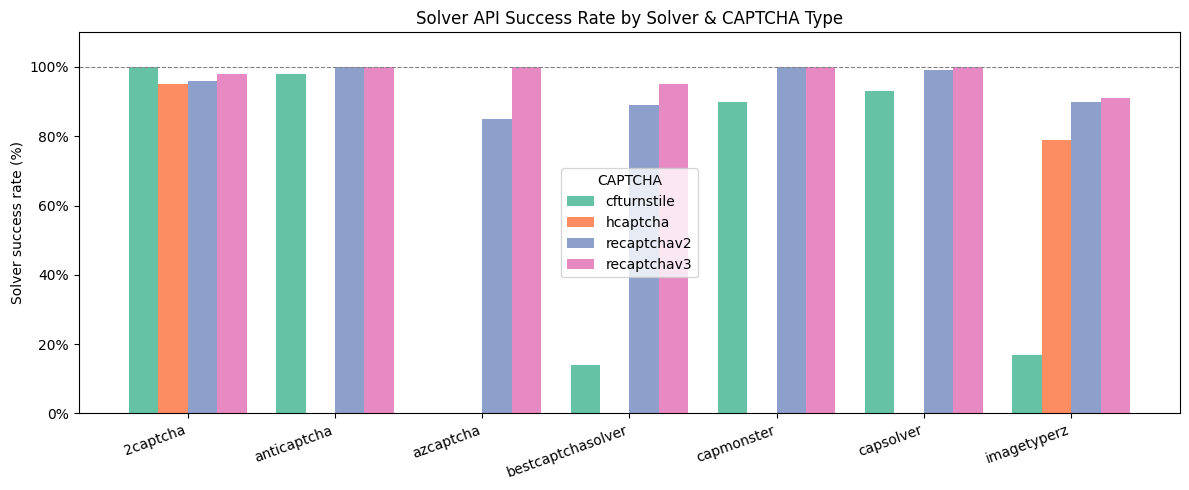

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(SOLVERS))
width = 0.2
offsets = np.linspace(-(len(CAPTCHAS)-1)/2, (len(CAPTCHAS)-1)/2, len(CAPTCHAS)) * width

for i, captcha in enumerate(CAPTCHAS):
    sub = overview[overview["captcha"] == captcha].set_index("solver").reindex(SOLVERS)
    ax.bar(x + offsets[i], sub["solver_sr"].fillna(0),
           width=width, label=captcha, color=palette_captchas[captcha])

ax.set_xticks(x)
ax.set_xticklabels(SOLVERS, rotation=20, ha="right")
ax.set_ylabel("Solver success rate (%)")
ax.set_title("Solver API Success Rate by Solver & CAPTCHA Type")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 110)
ax.legend(title="CAPTCHA")
ax.axhline(100, color="grey", lw=0.8, ls="--")
plt.tight_layout()
plt.show()

## 3. End-to-End Verification Success Rate

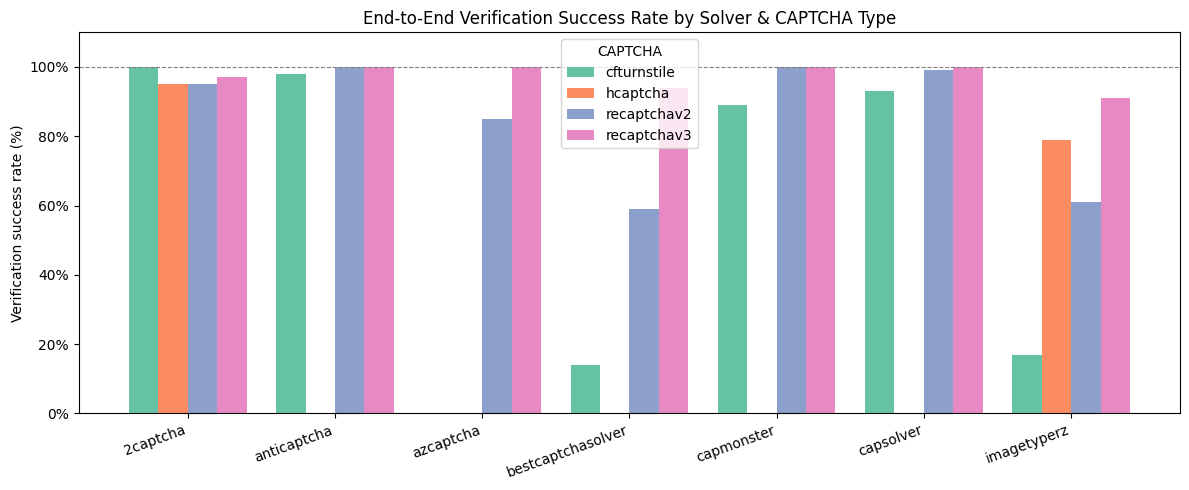

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, captcha in enumerate(CAPTCHAS):
    sub = overview[overview["captcha"] == captcha].set_index("solver").reindex(SOLVERS)
    ax.bar(x + offsets[i], sub["verify_sr"].fillna(0),
           width=width, label=captcha, color=palette_captchas[captcha])

ax.set_xticks(x)
ax.set_xticklabels(SOLVERS, rotation=20, ha="right")
ax.set_ylabel("Verification success rate (%)")
ax.set_title("End-to-End Verification Success Rate by Solver & CAPTCHA Type")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 110)
ax.legend(title="CAPTCHA")
ax.axhline(100, color="grey", lw=0.8, ls="--")
plt.tight_layout()
plt.show()

## 4. Heatmap — Verification Success Rate

In [ ]:
heat_data = overview.pivot(index="solver", columns="captcha", values="verify_sr")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heat_data, annot=True, fmt=".1f", cmap="RdYlGn",
    linewidths=0.5, linecolor="white",
    vmin=0, vmax=100, ax=ax,
    cbar_kws={"label": "Verification success rate (%)"}
)
ax.set_title("Verification Success Rate Heatmap (%)")
ax.set_xlabel("CAPTCHA type")
ax.set_ylabel("Solver")
plt.tight_layout()
plt.show()

## 5. Solve Duration Distribution

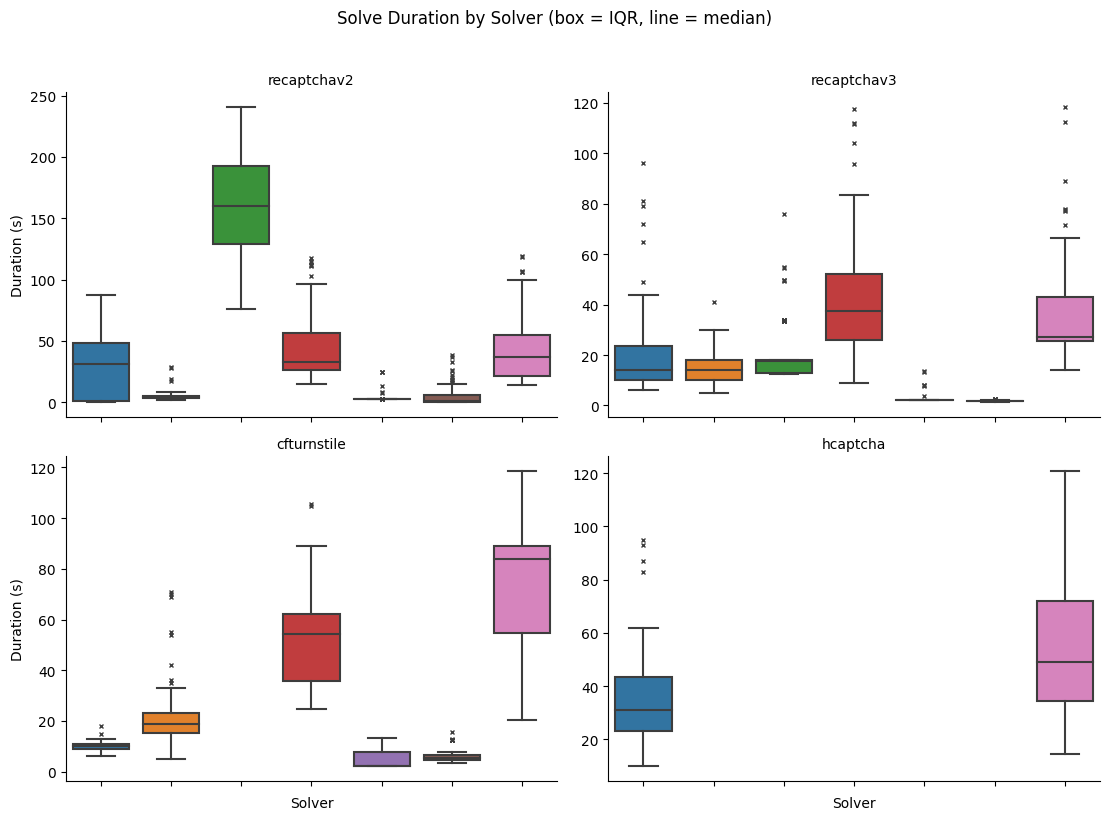

In [8]:
# Box-plot: duration by solver, faceted by captcha type
valid_duration = df[df["duration_s"].notna() & (df["duration_s"] < 300)]

g = sns.FacetGrid(
    valid_duration, col="captcha", col_wrap=2,
    height=4, aspect=1.4, sharey=False
)
g.map_dataframe(
    sns.boxplot, x="solver", y="duration_s",
    palette=palette_solvers, order=SOLVERS,
    flierprops={"marker": "x", "markersize": 3}
)
g.set_xticklabels(rotation=30, ha="right")
g.set_axis_labels("Solver", "Duration (s)")
g.set_titles(col_template="{col_name}")
g.figure.suptitle("Solve Duration by Solver (box = IQR, line = median)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Average Solve Time — Summary Table & Bar Chart

In [10]:
timing = (
    valid_duration.groupby(["solver", "captcha"])["duration_s"]
    .agg(["mean", "median", "std"])
    .round(2)
    .reset_index()
)

pivot_timing = timing.pivot(index="solver", columns="captcha", values="mean").round(1)
print("Mean solve time (seconds):")
pivot_timing

Mean solve time (seconds):


captcha,cfturnstile,hcaptcha,recaptchav2,recaptchav3
solver,,,,
2captcha,10.0,34.7,29.6,19.7
anticaptcha,21.5,NaN,4.3,14.7
azcaptcha,NaN,NaN,159.4,19.8
bestcaptchasolver,56.6,NaN,44.8,41.6
capmonster,4.9,NaN,3.2,2.7
capsolver,6.6,NaN,5.1,1.8
imagetyperz,76.3,56.4,43.9,36.7


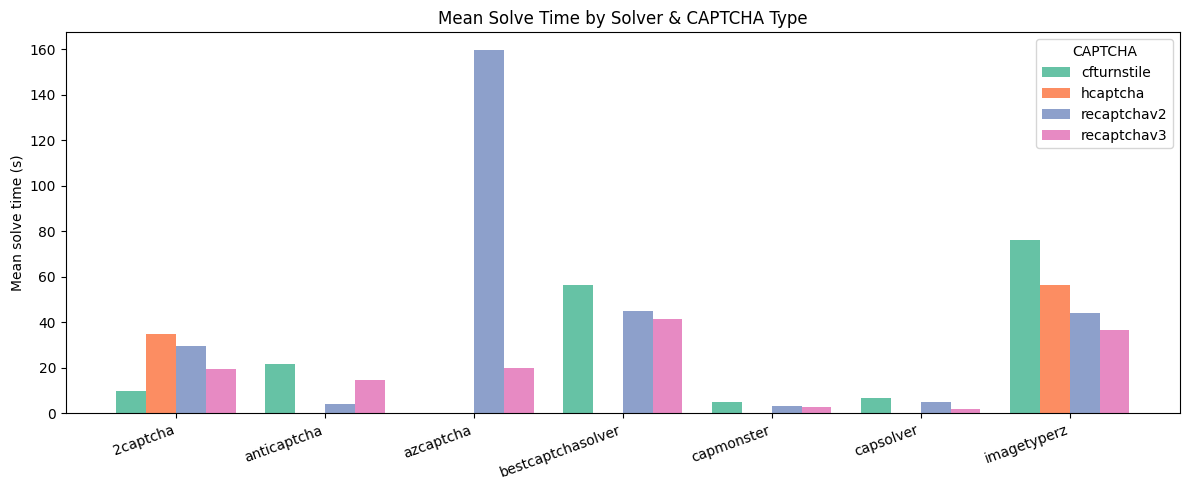

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, captcha in enumerate(CAPTCHAS):
    sub = timing[timing["captcha"] == captcha].set_index("solver").reindex(SOLVERS)
    ax.bar(x + offsets[i], sub["mean"].fillna(0),
           width=width, label=captcha, color=palette_captchas[captcha])

ax.set_xticks(x)
ax.set_xticklabels(SOLVERS, rotation=20, ha="right")
ax.set_ylabel("Mean solve time (s)")
ax.set_title("Mean Solve Time by Solver & CAPTCHA Type")
ax.legend(title="CAPTCHA")
plt.tight_layout()
plt.show()

## 7. LaTeX Table Export (Third-party Solvers)

Build the paper table directly from the database with fixed solver/captcha ordering and per-1K pricing.

In [8]:
df

,id,solver,captcha,task_id,solver_success,solver_status_code,solver_result,verify_success,verify_status_code,verify_result,verify_score,time_precision,startTime,finishTime,text_filename,text_expected,text_received,duration_s
0,1,capsolver,recaptchav2,698350ca-0888-48b1-bea2-e056ae2c4022,True,NaN,None,None,NaN,None,NaN,None,NaN,NaN,None,None,None,NaN
1,2,2captcha,recaptchav2,82555718919,True,200.0,"{""errorId"":0,""status"":""ready"",""solution"":{""gRe...",True,200.0,"{""success"":true,""challenge_ts"":""2026-04-29T18:...",NaN,from_solver,1.777486e+12,1.777486e+12,None,None,None,0.000
2,3,bestcaptchasolver,recaptchav2,1246624414,True,NaN,None,None,NaN,None,NaN,None,NaN,NaN,None,None,None,NaN
3,4,anticaptcha,recaptchav2,433578837,True,NaN,None,None,NaN,None,NaN,None,NaN,NaN,None,None,None,NaN
4,5,imagetyperz,recaptchav2,162245997,True,NaN,None,None,NaN,None,NaN,None,NaN,NaN,None,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,786,bestcaptchasolver,cfturnstile-non-interactive,1246728394,False,0.0,pipeline getTaskResult timeout,None,NaN,None,NaN,None,NaN,NaN,None,None,None,NaN
786,787,bestcaptchasolver,cfturnstile-non-interactive,1246729575,True,200.0,"{""id"":1246729575,""solution"":""1.5ZF37WtI6AjSnUV...",True,200.0,"{""action"":"""",""cdata"":"""",""challenge_ts"":""2026-0...",NaN,from_pipeline,1.777497e+12,1.777497e+12,None,None,None,93.811
787,788,bestcaptchasolver,cfturnstile-non-interactive,1246730411,True,200.0,"{""id"":1246730411,""solution"":""1.TPUFw2AUw_-NG0T...",True,200.0,"{""action"":"""",""cdata"":"""",""challenge_ts"":""2026-0...",NaN,from_pipeline,1.777497e+12,1.777498e+12,None,None,None,110.246
788,789,bestcaptchasolver,cfturnstile-non-interactive,1246731627,True,200.0,"{""id"":1246731627,""solution"":""1.s80rlnM4xLU0F2X...",True,200.0,"{""action"":"""",""cdata"":"""",""challenge_ts"":""2026-0...",NaN,from_pipeline,1.777498e+12,1.777498e+12,None,None,None,51.621


In [15]:
# Build a LaTeX table matching the paper layout from database metrics
import numpy as np
from pathlib import Path

# Success metric:
# - recaptchav3: success if verify_score > 0.5
# - all others: strict end-to-end success (solver_success AND verify_success)
# If required verifier data is missing for a solver/captcha pair, keep success as pending (\ph{}).
def calc_success_pct(g):
    captcha_name = str(g["captcha"].iloc[0])

    if captcha_name == "recaptchav3":
        score = pd.to_numeric(g["verify_score"], errors="coerce")
        score = score.dropna()
        return (score.gt(0.5).mean() * 100) if not score.empty else np.nan

    mask = g["verify_success"].notna()
    if not mask.any():
        return np.nan

    return (
        (
            g.loc[mask, "solver_success"].astype(bool)
            & g.loc[mask, "verify_success"].astype(bool)
        ).mean() * 100
    )


agg = (
    df.groupby(["solver", "captcha"]) 
    .apply(
        lambda g: pd.Series({
            "success_pct": calc_success_pct(g),
            "time_s": g["duration_s"].dropna().mean(),
        })
    )
    .reset_index()
)

metrics = {
    (r["solver"], r["captcha"]): {
        "success_pct": float(r["success_pct"]) if pd.notna(r["success_pct"]) else None,
        "time_s": float(r["time_s"]) if pd.notna(r["time_s"]) else None,
    }
    for _, r in agg.iterrows()
}

TABLE_SPEC = {
    "2captcha": [
        ("reCaptcha v2 (Check)", "recaptchav2", 2.99),
        ("reCaptcha v2 (Inv)", "recaptchav2-invis", 2.99),
        ("reCaptcha v3", "recaptchav3", 2.99),
        ("hCaptcha (E)", "hcaptcha-easy", 2.99),
        ("hCaptcha (H)", "hcaptcha", 2.99),
        ("Turnstile (Inv)", "cfturnstile-invis", 1.45),
        ("Turnstile (NI)", "cfturnstile-non-interactive", 1.45),
    ],
    "anticaptcha": [
        ("reCaptcha v2 (Check)", "recaptchav2", 2.00),
        ("reCaptcha v2 (Inv)", "recaptchav2-invis", 2.00),
        ("reCaptcha v3", "recaptchav3", 5.00),
        ("hCaptcha (E)", "hcaptcha-easy", 2.00),
        ("hCaptcha (H)", "hcaptcha", 2.00),
        ("Turnstile (Inv)", "cfturnstile-invis", 2.00),
        ("Turnstile (NI)", "cfturnstile-non-interactive", 2.00),
    ],
    "azcaptcha": [
        ("reCaptcha v2 (Check)", "recaptchav2", 1.00),
        ("reCaptcha v2 (Inv)", "recaptchav2-invis", 1.00),
        ("reCaptcha v3", "recaptchav3", 1.00),
        ("hCaptcha", "hcaptcha", None),
        ("Turnstile", "cfturnstile", None),
    ],
    "bestcaptchasolver": [
        ("reCaptcha v2 (Check)", "recaptchav2", 3.00),
        ("reCaptcha v2 (Inv)", "recaptchav2-invis", 3.00),
        ("reCaptcha v3", "recaptchav3", 3.00),
        ("hCaptcha (E)", "hcaptcha-easy", 2.00),
        ("hCaptcha (H)", "hcaptcha", 2.00),
        ("Turnstile (Inv)", "cfturnstile-invis", 1.80),
        ("Turnstile (NI)", "cfturnstile-non-interactive", 1.80),
    ],
    "capmonster": [
        ("reCaptcha v2 (Check)", "recaptchav2", 0.60),
        ("reCaptcha v2 (Inv)", "recaptchav2-invis", 0.60),
        ("reCaptcha v3", "recaptchav3", 1.00),
        ("hCaptcha (E)", "hcaptcha-easy", None),
        ("hCaptcha (H)", "hcaptcha", None),
        ("Turnstile (Inv)", "cfturnstile-invis", 1.30),
        ("Turnstile (NI)", "cfturnstile-non-interactive", 1.30),
    ],
    "capsolver": [
        ("reCaptcha v2 (Check)", "recaptchav2", 1.00),
        ("reCaptcha v2 (Inv)", "recaptchav2-invis", 1.00),
        ("reCaptcha v3", "recaptchav3", 3.00),
        ("hCaptcha (M)", "hcaptcha", None),
        ("Turnstile (Inv)", "cfturnstile-invis", 1.20),
        ("Turnstile (NI)", "cfturnstile-non-interactive", 1.20),
    ],
    "imagetyperz": [
        ("reCaptcha v2 (Check)", "recaptchav2", 2.10),
        ("reCaptcha v2 (Inv)", "recaptchav2-invis", 2.10),
        ("reCaptcha v3", "recaptchav3", 3.00),
        ("hCaptcha (E)", "hcaptcha-easy", 1.80),
        ("hCaptcha (H)", "hcaptcha", 1.80),
        ("Turnstile (Inv)", "cfturnstile-invis", 1.80),
        ("Turnstile (NI)", "cfturnstile-non-interactive", 1.80),
    ],
}

SOLVER_DISPLAY = {
    "2captcha": "2Captcha",
    "anticaptcha": "Anti-Captcha",
    "azcaptcha": "AZCaptcha",
    "bestcaptchasolver": "BestCaptchaSolver",
    "capmonster": "CapMonster",
    "capsolver": "Capsolver",
    "imagetyperz": "ImageTyperz",
}


def fmt_success(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return r"\ph{}"
    v = int(round(x))
    if v == 100:
        return r"\textbf{" + str(v) + "}"
    if v <= 50:
        return r"\textit{" + str(v) + "}"
    return str(v)


def fmt_time(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return r"\ph{}"
    return f"{x:.1f}"


def fmt_price(x):
    if x is None:
        return "--"
    return f"{x:.2f}"


lines = []
lines.append(r"\begin{table}[t!]")
lines.append(r"\centering")
lines.append(r"\scriptsize")
lines.append(r"\setlength{\tabcolsep}{3pt} % reduce column spacing")
lines.append(r"\renewcommand{\arraystretch}{1.15}")
lines.append(r"\begin{tabular}{l l c c c}")
lines.append(r"\toprule")
lines.append(r"\textbf{Solver} & \textbf{Captcha} & \textbf{Success (\%)} & \textbf{Time (s)} & \textbf{\$/1K} \\")
lines.append(r"\midrule")

solver_order = [
    "2captcha",
    "anticaptcha",
    "azcaptcha",
    "bestcaptchasolver",
    "capmonster",
    "capsolver",
    "imagetyperz",
]

for si, solver in enumerate(solver_order):
    rows = TABLE_SPEC[solver]
    for ri, (captcha_label, captcha_key, price) in enumerate(rows):
        row = metrics.get((solver, captcha_key), None)

        if price is None:
            success_txt = "--"
            time_txt = "--"
            price_txt = "--"
        else:
            success_txt = fmt_success(None if row is None else row["success_pct"])
            time_txt = fmt_time(None if row is None else row["time_s"])
            price_txt = fmt_price(price)

        solver_txt = (
            r"\multirow{" + str(len(rows)) + r"}{*}{" + SOLVER_DISPLAY[solver] + r"}"
            if ri == 0 else ""
        )
        lines.append(
            f"{solver_txt} & {captcha_label} & {success_txt} & {time_txt} & {price_txt} \\\\"
        )

    if si < len(solver_order) - 1:
        lines.append(r"\midrule")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(
    r"\caption{Third-party Captcha solvers. Succ. = success rate (\%), Time = seconds. \textbf{Bold}: 100\% success. \textit{Italic}: $\leq$50\%. \ph{}: pending. --: not supported.}"
)
lines.append(r"\label{tab:third_party_services_results}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)

out_path = Path("third_party_services_results.tex")
out_path.write_text(latex_table)
print(f"\nSaved LaTeX table to: {out_path.resolve()}")

\begin{table}[t!]
\centering
\scriptsize
\setlength{\tabcolsep}{3pt} % reduce column spacing
\renewcommand{\arraystretch}{1.15}
\begin{tabular}{l l c c c}
\toprule
\textbf{Solver} & \textbf{Captcha} & \textbf{Success (\%)} & \textbf{Time (s)} & \textbf{\$/1K} \\
\midrule
\multirow{7}{*}{2Captcha} & reCaptcha v2 (Check) & \textbf{100} & 32.2 & 2.99 \\
 & reCaptcha v2 (Inv) & \textbf{100} & 13.7 & 2.99 \\
 & reCaptcha v3 & 58 & 19.0 & 2.99 \\
 & hCaptcha (E) & \textbf{100} & 67.0 & 2.99 \\
 & hCaptcha (H) & 99 & 34.8 & 2.99 \\
 & Turnstile (Inv) & \textbf{100} & 7.2 & 1.45 \\
 & Turnstile (NI) & \textbf{100} & 7.8 & 1.45 \\
\midrule
\multirow{7}{*}{Anti-Captcha} & reCaptcha v2 (Check) & 98 & 8.7 & 2.00 \\
 & reCaptcha v2 (Inv) & \textbf{100} & 52.7 & 2.00 \\
 & reCaptcha v3 & 80 & 12.3 & 5.00 \\
 & hCaptcha (E) & \ph{} & \ph{} & 2.00 \\
 & hCaptcha (H) & \ph{} & \ph{} & 2.00 \\
 & Turnstile (Inv) & \textbf{100} & 20.3 & 2.00 \\
 & Turnstile (NI) & \textbf{100} & 26.1 & 2.00 \\
\midrule
\

## 7. Solver vs. Verifier Discrepancy

Cases where the solver API returned success but the CAPTCHA verification still failed — indicating a low-quality token.

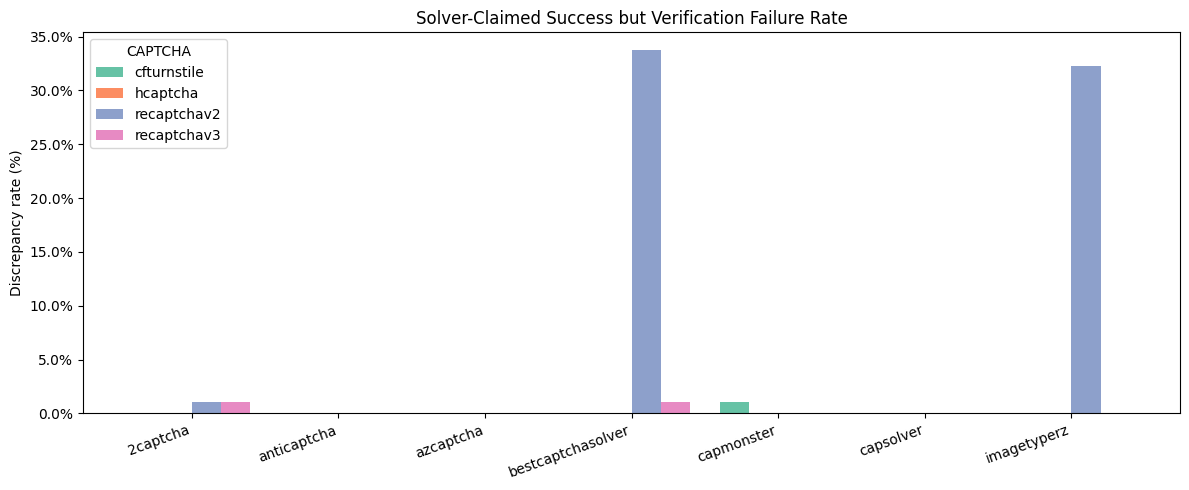

,solver,captcha,total_solver_ok,verify_fail,discrepancy_pct
10,bestcaptchasolver,recaptchav2,89,30,33.707865
20,imagetyperz,recaptchav2,90,29,32.222222
12,capmonster,cfturnstile,90,1,1.111111
11,bestcaptchasolver,recaptchav3,95,1,1.052632
2,2captcha,recaptchav2,96,1,1.041667
3,2captcha,recaptchav3,98,1,1.020408
13,capmonster,recaptchav2,100,0,0.000000
19,imagetyperz,hcaptcha,79,0,0.000000
18,imagetyperz,cfturnstile,17,0,0.000000
17,capsolver,recaptchav3,100,0,0.000000


In [12]:
verified_set = df[df["verify_success"].notna()].copy()
verified_set["verify_success"] = verified_set["verify_success"].astype(bool)

# Only rows where solver succeeded
solver_ok = verified_set[verified_set["solver_success"] == True]
disc = (
    solver_ok.groupby(["solver", "captcha"])
    .apply(lambda g: pd.Series({
        "total_solver_ok": len(g),
        "verify_fail": (~g["verify_success"]).sum(),
    }))
    .reset_index()
)
disc["discrepancy_pct"] = disc["verify_fail"] / disc["total_solver_ok"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
for i, captcha in enumerate(CAPTCHAS):
    sub = disc[disc["captcha"] == captcha].set_index("solver").reindex(SOLVERS)
    ax.bar(x + offsets[i], sub["discrepancy_pct"].fillna(0),
           width=width, label=captcha, color=palette_captchas[captcha])

ax.set_xticks(x)
ax.set_xticklabels(SOLVERS, rotation=20, ha="right")
ax.set_ylabel("Discrepancy rate (%)")
ax.set_title("Solver-Claimed Success but Verification Failure Rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title="CAPTCHA")
plt.tight_layout()
plt.show()

disc.sort_values("discrepancy_pct", ascending=False)

## 8. Overall Solver Ranking

Aggregate verification success rate across all CAPTCHA types tested for each solver.

In [13]:
ranking = (
    df.groupby("solver")
    .apply(lambda g: pd.Series({
        "total": len(g),
        "captcha_types": g["captcha"].nunique(),
        "solver_sr": g["solver_success"].mean() * 100,
        "verify_sr": g["verify_success"].dropna().mean() * 100,
        "mean_duration_s": g["duration_s"].clip(lower=0).mean(),
    }))
    .reset_index()
    .sort_values("verify_sr", ascending=False)
    .reset_index(drop=True)
)
ranking.index += 1  # rank starting at 1
ranking.round(2)

,solver,total,captcha_types,solver_sr,verify_sr,mean_duration_s
1,anticaptcha,300.0,3.0,99.33,100.00,13.47
2,azcaptcha,200.0,2.0,92.50,100.00,83.91
3,capsolver,300.0,3.0,97.33,100.00,4.44
4,capmonster,300.0,3.0,96.67,99.66,3.57
5,2captcha,400.0,4.0,97.25,99.49,23.31
6,imagetyperz,400.0,4.0,69.25,89.53,47.10
7,bestcaptchasolver,300.0,3.0,66.00,84.34,44.11


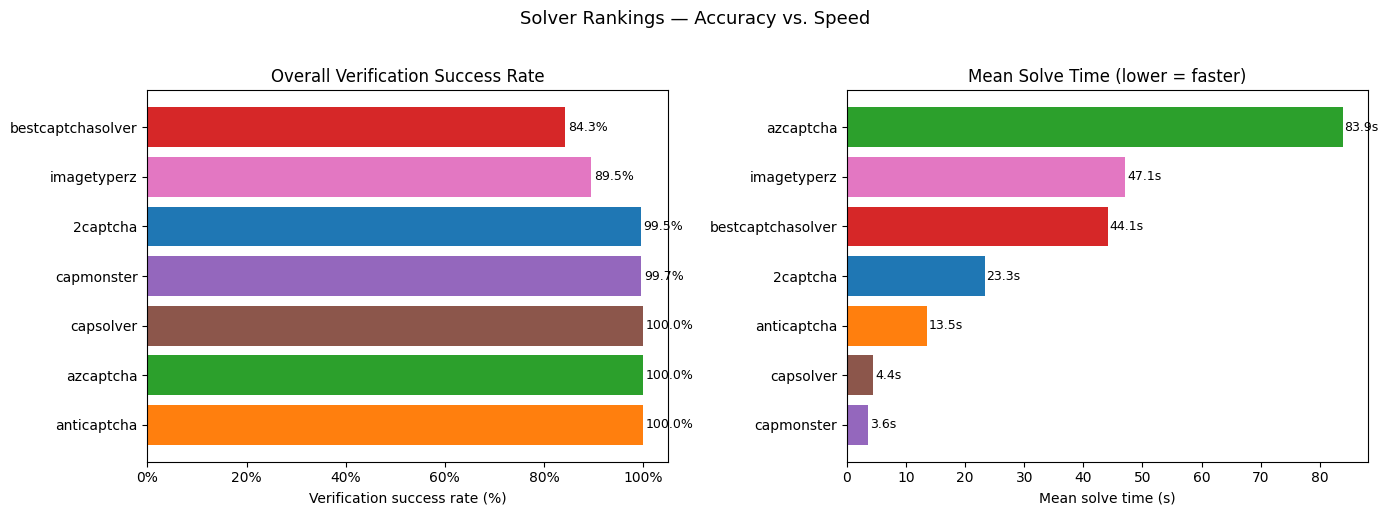

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Verification success rate
ax = axes[0]
bars = ax.barh(
    ranking["solver"], ranking["verify_sr"],
    color=[palette_solvers[s] for s in ranking["solver"]]
)
ax.set_xlabel("Verification success rate (%)")
ax.set_title("Overall Verification Success Rate")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 105)
for bar, val in zip(bars, ranking["verify_sr"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

# Mean duration
ax = axes[1]
rank_by_speed = ranking.sort_values("mean_duration_s")
bars = ax.barh(
    rank_by_speed["solver"], rank_by_speed["mean_duration_s"],
    color=[palette_solvers[s] for s in rank_by_speed["solver"]]
)
ax.set_xlabel("Mean solve time (s)")
ax.set_title("Mean Solve Time (lower = faster)")
for bar, val in zip(bars, rank_by_speed["mean_duration_s"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}s", va="center", fontsize=9)

plt.suptitle("Solver Rankings — Accuracy vs. Speed", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Per-CAPTCHA Type Deep-Dive

In [15]:
for captcha in CAPTCHAS:
    sub = overview[overview["captcha"] == captcha].sort_values("verify_sr", ascending=False)
    if sub.empty:
        continue
    print(f"\n{'='*50}")
    print(f"  {captcha.upper()}")
    print(f"{'='*50}")
    print(sub[["solver", "total", "solver_sr", "verify_sr"]].to_string(index=False))


  CFTURNSTILE
           solver  total  solver_sr  verify_sr
         2captcha    100      100.0      100.0
      anticaptcha    100       98.0       98.0
        capsolver    100       93.0       93.0
       capmonster    100       90.0       89.0
      imagetyperz    100       17.0       17.0
bestcaptchasolver    100       14.0       14.0

  HCAPTCHA
     solver  total  solver_sr  verify_sr
   2captcha    100       95.0       95.0
imagetyperz    100       79.0       79.0

  RECAPTCHAV2
           solver  total  solver_sr  verify_sr
      anticaptcha    100      100.0      100.0
       capmonster    100      100.0      100.0
        capsolver    100       99.0       99.0
         2captcha    100       96.0       95.0
        azcaptcha    100       85.0       85.0
      imagetyperz    100       90.0       61.0
bestcaptchasolver    100       89.0       59.0

  RECAPTCHAV3
           solver  total  solver_sr  verify_sr
      anticaptcha    100      100.0      100.0
        azcaptcha    

## 10. Status Code Analysis

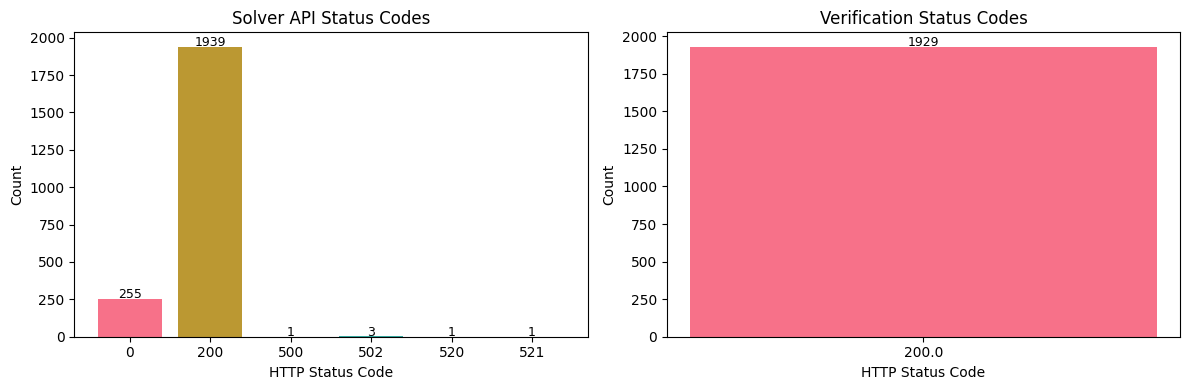

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], "solver_status_code", "Solver API Status Codes"),
    (axes[1], "verify_status_code", "Verification Status Codes"),
]:
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette("husl", len(counts)))
    ax.set_title(title)
    ax.set_xlabel("HTTP Status Code")
    ax.set_ylabel("Count")
    for i, (code, cnt) in enumerate(counts.items()):
        ax.text(i, cnt + 5, str(cnt), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 11. Key Findings Summary

In [17]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

best_acc  = ranking.iloc[0]
worst_acc = ranking.iloc[-1]
fastest   = ranking.sort_values("mean_duration_s").iloc[0]
slowest   = ranking.sort_values("mean_duration_s").iloc[-1]

print(f"\nBest verification accuracy : {best_acc['solver']} ({best_acc['verify_sr']:.1f}%)")
print(f"Worst verification accuracy: {worst_acc['solver']} ({worst_acc['verify_sr']:.1f}%)")
print(f"Fastest solver (mean)      : {fastest['solver']} ({fastest['mean_duration_s']:.1f}s)")
print(f"Slowest solver (mean)      : {slowest['solver']} ({slowest['mean_duration_s']:.1f}s)")

print("\nSolvers supporting all 4 CAPTCHA types:")
all4 = ranking[ranking["captcha_types"] == 4]["solver"].tolist()
print(" ", all4 if all4 else "None")

print("\nHighest discrepancy (solver ok but verify fail):")
top_disc = disc.sort_values("discrepancy_pct", ascending=False).head(3)
for _, row in top_disc.iterrows():
    print(f"  {row['solver']} / {row['captcha']}: {row['discrepancy_pct']:.1f}%")

print("\nCFTurnstile coverage (not all solvers tested):")
cf_solvers = overview[overview["captcha"] == "cfturnstile"]["solver"].tolist()
print(" ", cf_solvers)

print("\nhCaptcha coverage:")
hc_solvers = overview[overview["captcha"] == "hcaptcha"]["solver"].tolist()
print(" ", hc_solvers)

KEY FINDINGS

Best verification accuracy : anticaptcha (100.0%)
Worst verification accuracy: bestcaptchasolver (84.3%)
Fastest solver (mean)      : capmonster (3.6s)
Slowest solver (mean)      : azcaptcha (83.9s)

Solvers supporting all 4 CAPTCHA types:
  ['2captcha', 'imagetyperz']

Highest discrepancy (solver ok but verify fail):
  bestcaptchasolver / recaptchav2: 33.7%
  imagetyperz / recaptchav2: 32.2%
  capmonster / cfturnstile: 1.1%

CFTurnstile coverage (not all solvers tested):
  ['2captcha', 'anticaptcha', 'bestcaptchasolver', 'capmonster', 'capsolver', 'imagetyperz']

hCaptcha coverage:
  ['2captcha', 'imagetyperz']
